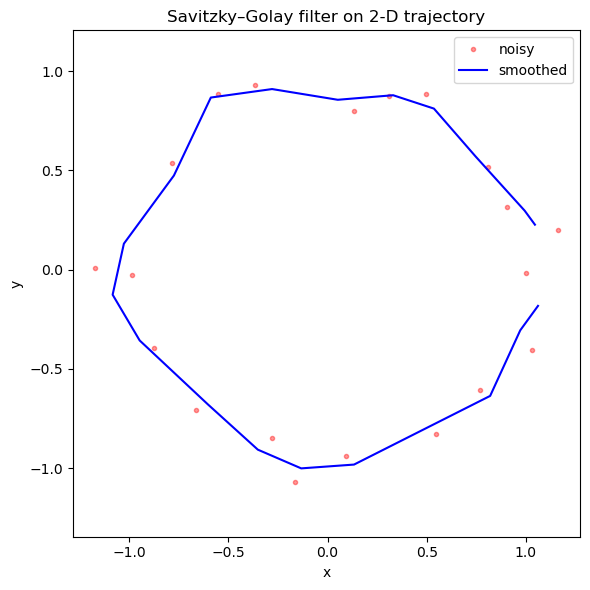

In [7]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from hydrax.algs.alg_extension_utils import colorize_time_series, make_savgol_filter, shift_tensor, savgol_coeffs


# ---------------------------------------------------------------------
# 2. Create noisy test trajectories: shape (num_samples, num_points, 2)
# ---------------------------------------------------------------------

key = jax.random.PRNGKey(0)
num_samples = 5
num_points = 20

t = jnp.linspace(0.0, 2 * jnp.pi, num_points)

# True smooth trajectory: circle
circle = jnp.stack([jnp.cos(t), jnp.sin(t)], axis=-1)  # (num_points, 2)

# Add noise per sample
noise = 0.1 * jax.random.normal(key, (num_samples, num_points, 2))
trajs = circle + noise  # (num_samples, num_points, 2)

# ---------------------------------------------------------------------
# 3. Build and apply the Savitzky–Golay filter
# ---------------------------------------------------------------------

savgol = make_savgol_filter(
    window_length=5,
    polyorder=3,
    axis=1,    # filter along trajectory/time axis
)

smoothed = savgol(trajs)

# ---------------------------------------------------------------------
# 4. Plot results for the first sample
# ---------------------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.plot(trajs[0, :, 0], trajs[0, :, 1], "r.", alpha=0.4, label="noisy")
plt.plot(smoothed[0, :, 0], smoothed[0, :, 1], "b-", label="smoothed")
plt.legend()
plt.title("Savitzky–Golay filter on 2-D trajectory")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.tight_layout()
plt.show()